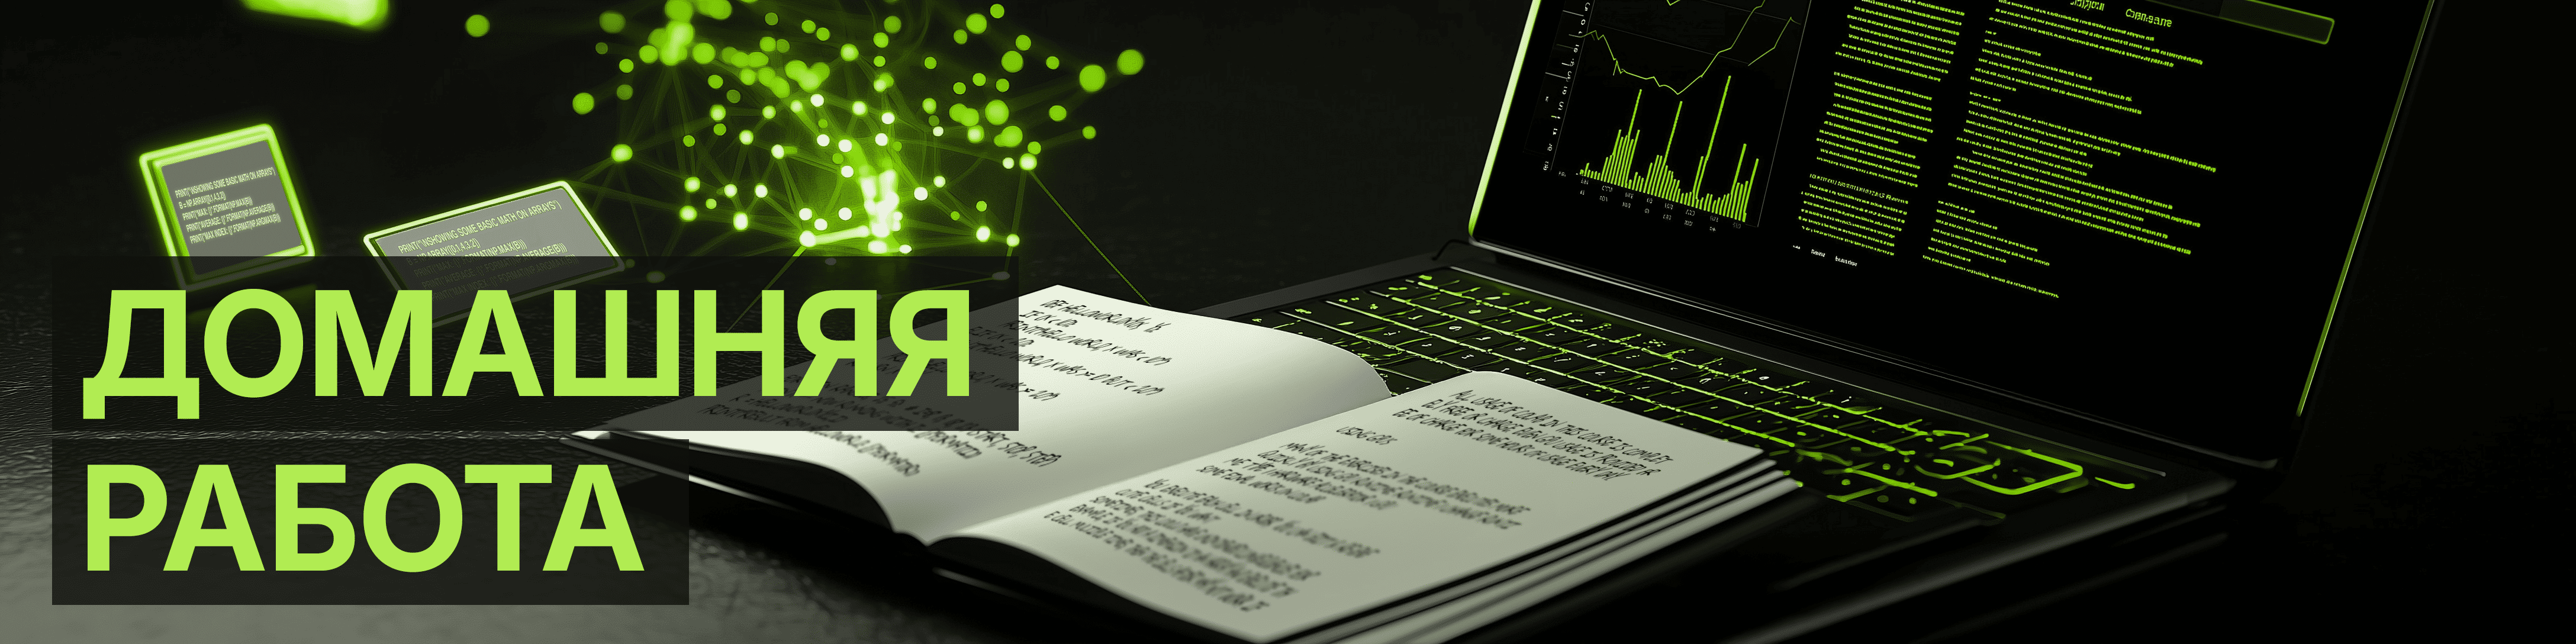

**Навигация по уроку**

1. [Анализ временных рядов с помощью НС](https://colab.research.google.com/drive/1q9nM-aWF6wZ2XuBxjQEAgjKxrL45axit)
2. [Сравнение архитектур нейронных сетей для обработки временных рядов](https://colab.research.google.com/drive/1-D-qXFYJ9b5sLLz_CFkUYmR-I2tM7KO2)
3. Домашняя работа

**В домашней работе вам необходимо:**
1. Выбрать любую понравившуюся модель из [практической](https://colab.research.google.com/drive/1-D-qXFYJ9b5sLLz_CFkUYmR-I2tM7KO2) части урока.
2. Используя известный [датасет](https://storage.yandexcloud.net/academy.ai/AAPL.csv) котировок Apple, обучить модель. Вывести графики из урока: график процесса обучения, сопоставления базового и прогнозного рядов, а также график автокорреляции.
3. Для получения трех проходных баллов за урок необходимо скорректировать код урока для данных с batch_size не равному 1.
4. Хотите 4 балла? Возьмите полносвязанную модель или с одномерной сверткой. Добейтесь подбором параметров и выбором архитектуры идеального графика автокорреляции без холмиков, равномерно спадающих графиков эталонной и прогнозной автокорреляции, максимально близко друг к другу.
5. Для получения дополнительного балла вам необходимо избавиться от тренда с помощью дифференцирования в датасете.
6. Еще один балл можно получить сверху, если догадаетесь как на графике сопоставления базового и прогнозного рядов отобразить реальную дату, а не относительную.

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Размер датасета: (2577, 1)
Период: 2014-01-02 00:00:00 — 2024-03-28 00:00:00


,Adj Close
Date,
2014-01-02,17.296652
2014-01-03,16.916719
2014-01-06,17.008968
2014-01-07,16.887323
2014-01-08,16.994270


,Adj Close
Date,
2024-03-22,172.279999
2024-03-25,170.850006
2024-03-26,169.710007
2024-03-27,173.309998
2024-03-28,171.479996


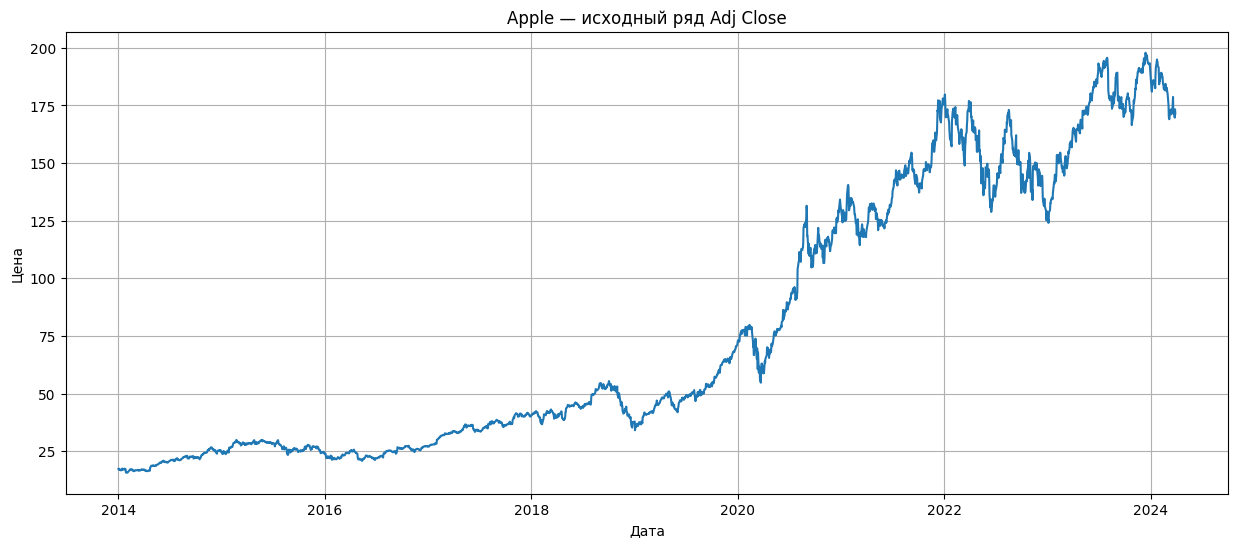

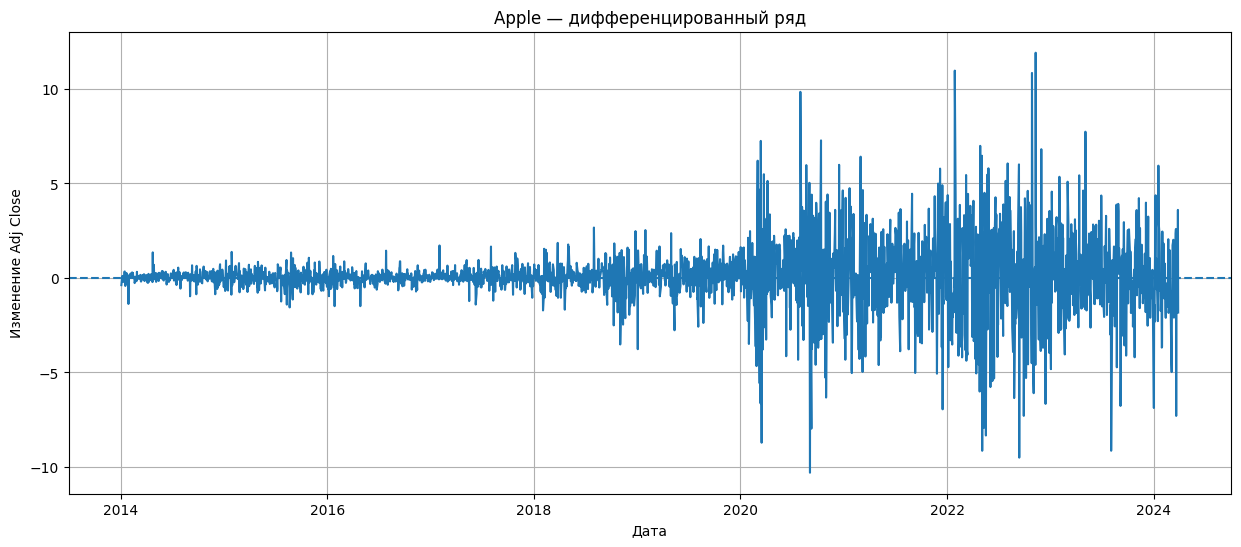

TRAIN: 2014-01-03 00:00:00 — 2022-03-09 00:00:00 (2060, 1)
VALIDATION: 2022-03-10 00:00:00 — 2023-03-20 00:00:00 (258, 1)
TEST: 2023-03-21 00:00:00 — 2024-03-28 00:00:00 (258, 1)
Среднее TRAIN после нормализации: 0.0
STD TRAIN после нормализации: 1.0
BATCH_SIZE: 32
Форма первого X-пакета: (32, 14, 1)
Форма первого y-пакета: (32, 1)

Обучаем: Dense_w14_96_48
Лучшая val_loss: 5.837225
Autocorr score: 0.156728

Обучаем: Dense_w21_128_64
Лучшая val_loss: 5.824010
Autocorr score: 0.173710

Обучаем: Dense_w30_160_64


Лучшая val_loss: 5.939772
Autocorr score: 0.207812


,name,window,units_1,units_2,dropout,learning_rate,corr_score,best_val_loss,model_path
0,Dense_w14_96_48,14,96,48,0.03,0.0010,0.156728,5.837225,/content/Dense_w14_96_48.keras
1,Dense_w21_128_64,21,128,64,0.05,0.0007,0.173710,5.824010,/content/Dense_w21_128_64.keras
2,Dense_w30_160_64,30,160,64,0.05,0.0005,0.207812,5.939772,/content/Dense_w30_160_64.keras


Выбран лучший вариант: Dense_w14_96_48
Длина окна: 14
Autocorr score: 0.15672827203349166


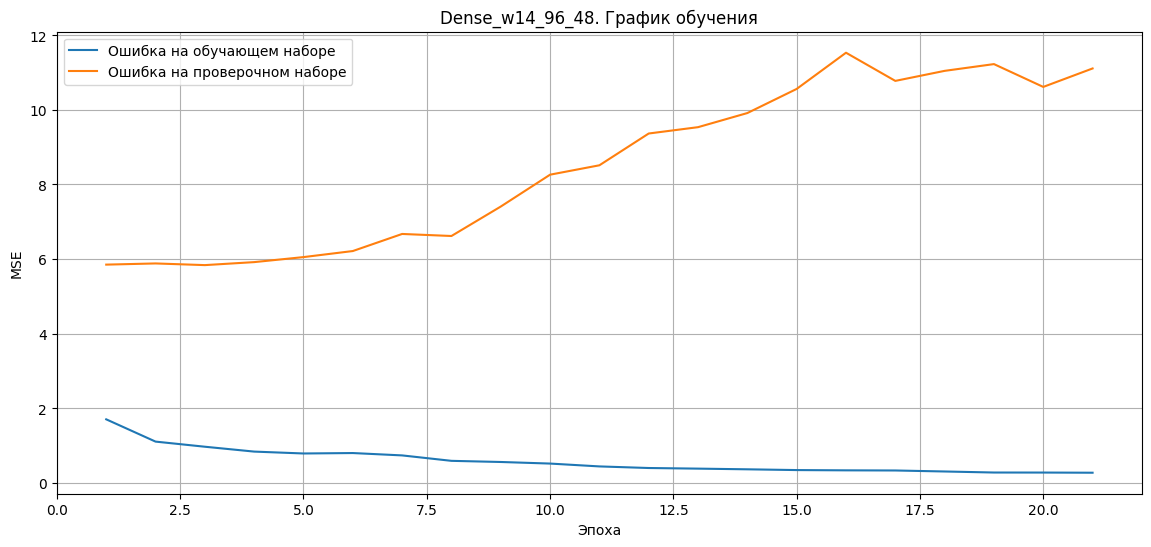

Тестовых прогнозов: 244
Первый прогноз: 2023-04-11 00:00:00
Последний прогноз: 2024-03-28 00:00:00
MAE по цене: 1.6689
MAPE по цене: 0.93%
Точность направления движения: 46.31%


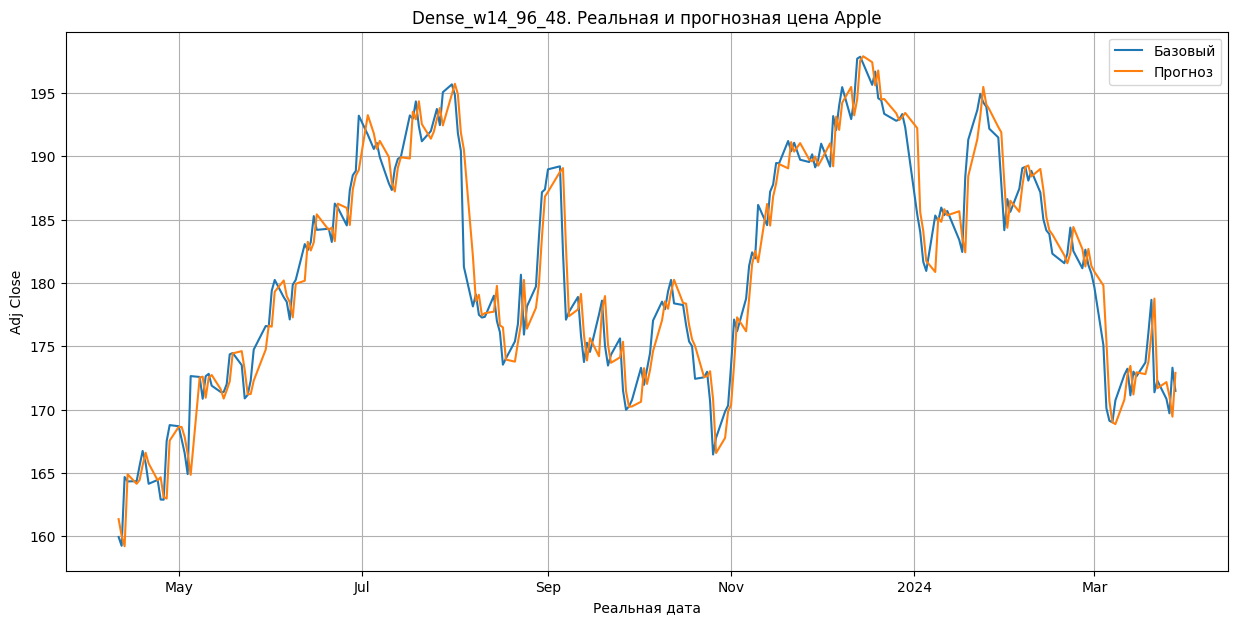

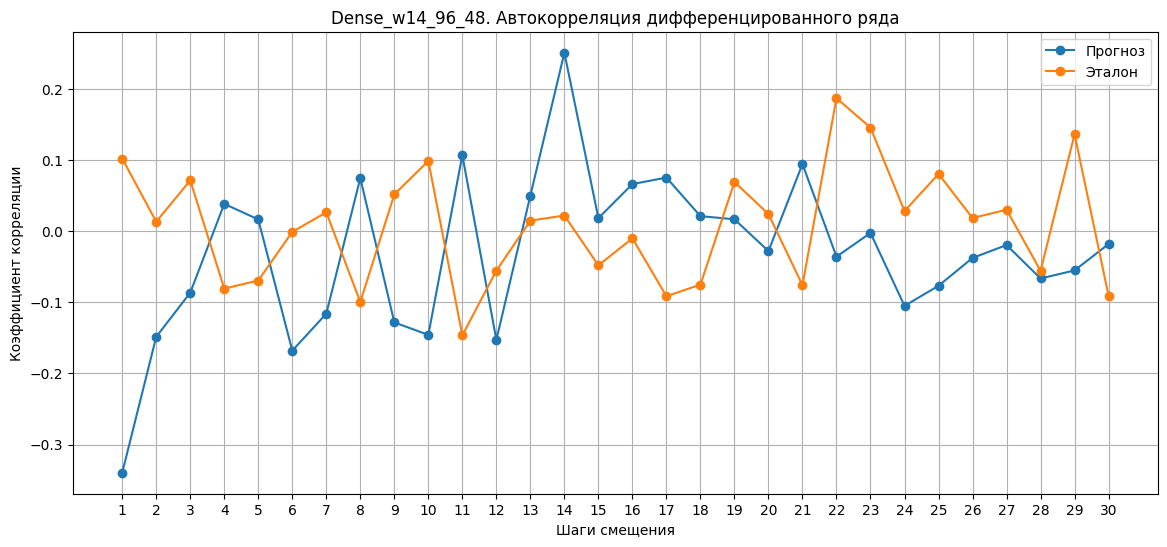

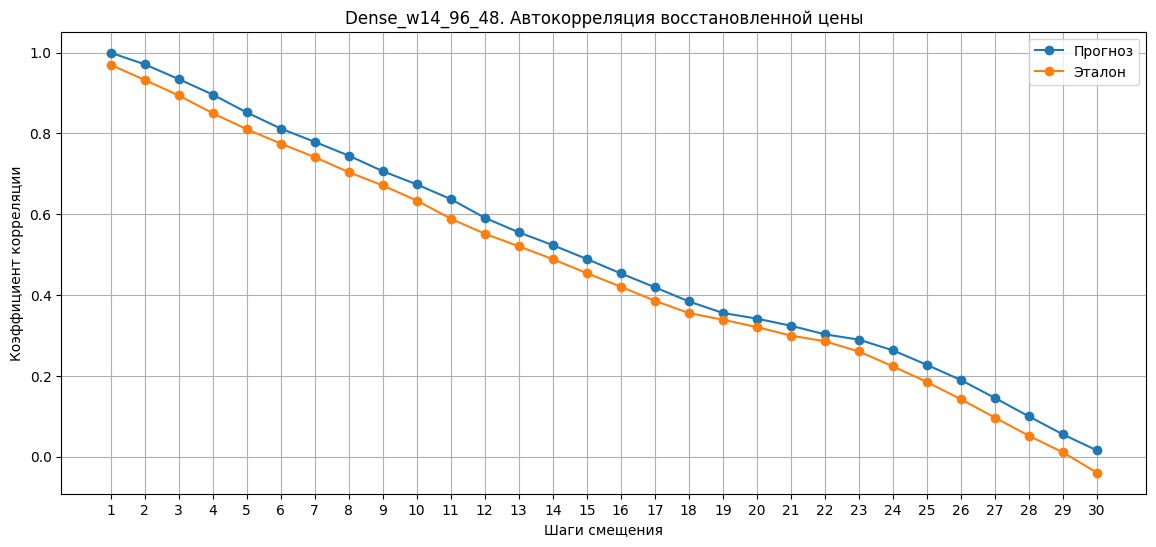

,Date,Previous price,Real price,Predicted price,Absolute error,"Error, %"
224,2024-03-01,180.750000,179.660004,180.893605,1.233601,0.686631
225,2024-03-04,179.660004,175.100006,179.805104,4.705098,2.687092
226,2024-03-05,175.100006,170.119995,175.417173,5.297178,3.113789
227,2024-03-06,170.119995,169.119995,170.677016,1.557021,0.920660
228,2024-03-07,169.119995,169.000000,168.992467,0.007533,0.004458
229,2024-03-08,169.000000,170.729996,168.857936,1.872060,1.096504
230,2024-03-11,170.729996,172.750000,170.791938,1.958062,1.133466
231,2024-03-12,172.750000,173.229996,172.727352,0.502644,0.290160
232,2024-03-13,173.229996,171.130005,173.449182,2.319177,1.355214
233,2024-03-14,171.130005,173.000000,171.198528,1.801472,1.041313


In [1]:

# Импорт
import os
import random

import numpy as np
import pandas as pd

# Графики
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)

# Генератор временных рядов — как в практическом уроке
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормализация
from sklearn.preprocessing import StandardScaler


# Фиксируем случайность для более воспроизводимого результата
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ===
# Датасет
DATASET_URL = (
    "https://storage.yandexcloud.net/academy.ai/"
    "AAPL.csv"
)


# Загружаем только дату и Adj Close
# parse_dates сразу переводит Date в datetime
price = pd.read_csv(
    DATASET_URL,
    usecols=[
        "Date",
        "Adj Close",
    ],
    parse_dates=["Date"],
)


# Сортируем строго по времени, для временных рядов нельзя случайно перемешивать даты
price = (
    price
    .sort_values("Date")
    .set_index("Date")
    .dropna()
)


print("Размер датасета:", price.shape)
print(
    "Период:",
    price.index.min(),
    "—",
    price.index.max(),
)

display(price.head())
display(price.tail())

# ===
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    price.index,
    price["Adj Close"],
)

plt.title(
    "Apple — исходный ряд Adj Close"
)

plt.xlabel("Дата")
plt.ylabel("Цена")
plt.grid()
plt.show()

# ===
# Первая разность временного ряда.
# Первая строка станет NaN, потому что для неё нет предыдущей цены.
diff_price = (
    price[["Adj Close"]]
    .diff()
    .dropna()
)

# Переименуем колонку, чтобы было понятно, что теперь это не цена, а изменение цены.
diff_price.columns = [
    "Adj Close diff"
]


plt.figure(
    figsize=(15, 6)
)

plt.plot(
    diff_price.index,
    diff_price["Adj Close diff"],
)

plt.axhline(
    0,
    linestyle="--",
)

plt.title(
    "Apple — дифференцированный ряд"
)

plt.xlabel("Дата")
plt.ylabel("Изменение Adj Close")
plt.grid()
plt.show()

# ===
# Число точек после дифференцирования
data_len = len(diff_price)

# Границы хронологического разбиения
train_end = int(
    data_len * 0.80
)

val_end = int(
    data_len * 0.90
)


# Разбиваем строго по времени
train_data = diff_price.iloc[
    :train_end
].copy()

val_data = diff_price.iloc[
    train_end:val_end
].copy()

test_data = diff_price.iloc[
    val_end:
].copy()


print(
    "TRAIN:",
    train_data.index.min(),
    "—",
    train_data.index.max(),
    train_data.shape,
)

print(
    "VALIDATION:",
    val_data.index.min(),
    "—",
    val_data.index.max(),
    val_data.shape,
)

print(
    "TEST:",
    test_data.index.min(),
    "—",
    test_data.index.max(),
    test_data.shape,
)

# ===
# Создаём объект нормализации
scaler = StandardScaler()


# Обучаем scaler только на обучающей части ряда
scaled_train_data = scaler.fit_transform(
    train_data
)


# Validation и test только преобразуем
scaled_val_data = scaler.transform(
    val_data
)

scaled_test_data = scaler.transform(
    test_data
)


print(
    "Среднее TRAIN после нормализации:",
    scaled_train_data.mean(),
)

print(
    "STD TRAIN после нормализации:",
    scaled_train_data.std(),
)

# ===
def history_plot(history, title):
    """
    График процесса обучения:
    train loss и validation loss.
    """
    epochs = range(
        1,
        len(history.history["loss"]) + 1,
    )

    plt.figure(
        figsize=(14, 6)
    )

    plt.plot(
        epochs,
        history.history["loss"],
        label="Ошибка на обучающем наборе",
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        label="Ошибка на проверочном наборе",
    )

    plt.title(
        f"{title}. График обучения"
    )

    plt.xlabel("Эпоха")
    plt.ylabel("MSE")
    plt.grid()
    plt.legend()
    plt.show()


def correlate(a, b):
    """
    Коэффициент корреляции двух одномерных рядов.

    Если в одном из участков дисперсия практически нулевая,
    корреляция математически неопределена — возвращаем 0.
    """
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)

    if (
        len(a) < 2
        or len(b) < 2
        or np.std(a) < 1e-12
        or np.std(b) < 1e-12
    ):
        return 0.0

    return np.corrcoef(
        a,
        b,
    )[0, 1]


def generator_targets(generator):
    """
    Собирает все правильные ответы из TimeseriesGenerator.

    Это изменение относительно варианта, где batch_size=1.

    При batch_size=32 generator[i][1] содержит сразу несколько правильных ответов.
    Нельзя считать, что один индекс генератора соответствует одному примеру.
    """
    batches = []

    for batch_index in range(
        len(generator)
    ):
        _, y_batch = generator[
            batch_index
        ]

        batches.append(
            np.asarray(y_batch)
        )

    return np.concatenate(
        batches,
        axis=0,
    )


def get_pred(
    model,
    generator,
    scaler,
):
    """
    Получаем прогноз и правильные ответы.

    model.predict(generator) автоматически обрабатывает
    произвольный batch_size.

    generator_targets() корректно собирает y_true
    даже для последнего неполного пакета.
    """

    # Прогноз в нормализованной шкале
    y_pred_scaled = model.predict(
        generator,
        verbose=0,
    )

    # Настоящие ответы в нормализованной шкале
    y_true_scaled = generator_targets(
        generator
    )

    # Возвращаем исходный масштаб разностей цены
    y_pred = scaler.inverse_transform(
        y_pred_scaled
    )

    y_true = scaler.inverse_transform(
        y_true_scaled
    )

    return (
        y_pred,
        y_true,
    )


def correlation_curves(
    y_pred,
    y_true,
    break_step=30,
):
    """
    Возвращает данные для графика корреляций из урока

    cross_corr:
        корреляция эталонного ряда с прогнозом при смещении.

    auto_corr:
        автокорреляция эталонного ряда.
    """

    y_pred = np.asarray(
        y_pred
    ).reshape(-1)

    y_true = np.asarray(
        y_true
    ).reshape(-1)

    max_step = min(
        len(y_true) - 2,
        break_step,
    )

    steps = np.arange(
        1,
        max_step + 1,
    )

    cross_corr = np.array(
        [
            correlate(
                y_true[:-step],
                y_pred[step:],
            )
            for step in steps
        ]
    )

    auto_corr = np.array(
        [
            correlate(
                y_true[:-step],
                y_true[step:],
            )
            for step in steps
        ]
    )

    return (
        steps,
        cross_corr,
        auto_corr,
    )


def show_corr(
    y_pred,
    y_true,
    title="",
    break_step=30,
):
    """
    График автокорреляции в стиле практического урока
    """

    (
        steps,
        cross_corr,
        auto_corr,
    ) = correlation_curves(
        y_pred,
        y_true,
        break_step=break_step,
    )

    plt.figure(
        figsize=(14, 6)
    )

    plt.plot(
        steps,
        cross_corr,
        marker="o",
        label="Прогноз",
    )

    plt.plot(
        steps,
        auto_corr,
        marker="o",
        label="Эталон",
    )

    plt.title(title)
    plt.xlabel("Шаги смещения")
    plt.ylabel(
        "Коэффициент корреляции"
    )
    plt.xticks(steps)
    plt.grid()
    plt.legend()
    plt.show()


def autocorr_quality(
    y_pred,
    y_true,
    break_step=20,
):
    """
    Численный критерий для автоматического подбора модели.

    Чем меньше score, тем ближе прогнозная корреляция к эталонной.

    Этот score нужен только для выбора архитектуры.
    Он не заменяет график автокорреляции.
    """

    (
        steps,
        cross_corr,
        auto_corr,
    ) = correlation_curves(
        y_pred,
        y_true,
        break_step=break_step,
    )

    # Насколько далеко прогнозная кривая от эталонной
    distance = np.mean(
        np.abs(
            cross_corr - auto_corr
        )
    )

    # Положительное изменение — потенциальный "холмик"
    rises = np.maximum(
        np.diff(cross_corr),
        0,
    )

    hump_penalty = (
        np.mean(rises)
        if len(rises)
        else 0.0
    )

    score = (
        distance
        + 0.5 * hump_penalty
    )

    return float(score)


def show_predict_dates(
    dates,
    y_pred_price,
    y_true_price,
    title="",
):
    """
    Сопоставляет реальный и прогнозный ряды.

    В отличие от функции урока по оси X здесь
    находится реальная дата, а не номер точки.
    """

    plt.figure(
        figsize=(15, 7)
    )

    plt.plot(
        dates,
        y_true_price,
        label="Базовый",
    )

    plt.plot(
        dates,
        y_pred_price,
        label="Прогноз",
    )

    plt.title(title)
    plt.xlabel("Реальная дата")
    plt.ylabel("Adj Close")

    # Автоматически выбираем удобную частоту подписей дат
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(
        locator
    )

    ax = plt.gca()
    ax.xaxis.set_major_locator(
        locator
    )
    ax.xaxis.set_major_formatter(
        formatter
    )

    plt.grid()
    plt.legend()
    plt.show()

# ===
# Размер пакета специально НЕ равен 1
BATCH_SIZE = 32

# Один входной признак: изменение Adj Close
N_FEATURES = 1


def make_generator(
    data,
    window,
    batch_size=BATCH_SIZE,
):
    """
    Создаёт TimeseriesGenerator.

    По window предыдущим изменениям цены
    прогнозируется следующее изменение.
    """
    return TimeseriesGenerator(
        data,
        data,
        length=window,
        sampling_rate=1,
        stride=1,
        batch_size=batch_size,
        shuffle=False,
    )


# Небольшая демонстрация batch_size != 1
demo_generator = make_generator(
    scaled_train_data,
    window=14,
)

x_demo, y_demo = demo_generator[0]

print(
    "BATCH_SIZE:",
    BATCH_SIZE,
)

print(
    "Форма первого X-пакета:",
    x_demo.shape,
)

print(
    "Форма первого y-пакета:",
    y_demo.shape,
)

assert BATCH_SIZE != 1
assert x_demo.shape[0] > 1

# ===
def build_dense_model(
    window,
    units_1,
    units_2,
    dropout=0.05,
    learning_rate=1e-3,
):
    """
    Создаёт полносвязную модель временного ряда.
    """

    model = Sequential(
        [
            # Вход:
            # window временных точек × 1 признак
            Input(
                shape=(
                    window,
                    N_FEATURES,
                )
            ),

            # Как в Dense-модели урока:
            # Dense применяется к каждой точке временного окна
            Dense(
                units_1,
                activation="relu",
            ),

            # Затем объединяем всё окно в один вектор
            Flatten(),

            BatchNormalization(),

            # Дополнительный полносвязный слой
            Dense(
                units_2,
                activation="relu",
            ),

            # Маленький Dropout — защита от переобучения
            Dropout(
                dropout
            ),

            # Один линейный выход:
            # прогноз изменения цены следующего дня
            Dense(
                1,
                activation="linear",
            ),
        ]
    )


    # В уроке для регрессии используется MSE
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
    )

    return model

# ===
# Набор кандидатов.
# При желании сюда легко добавить ещё варианты.
CANDIDATES = [
    {
        "name": "Dense_w14_96_48",
        "window": 14,
        "units_1": 96,
        "units_2": 48,
        "dropout": 0.03,
        "learning_rate": 1e-3,
    },
    {
        "name": "Dense_w21_128_64",
        "window": 21,
        "units_1": 128,
        "units_2": 64,
        "dropout": 0.05,
        "learning_rate": 7e-4,
    },
    {
        "name": "Dense_w30_160_64",
        "window": 30,
        "units_1": 160,
        "units_2": 64,
        "dropout": 0.05,
        "learning_rate": 5e-4,
    },
]


results = []
histories = {}


for config in CANDIDATES:

    print(
        "\n"
        + "=" * 70
    )

    print(
        "Обучаем:",
        config["name"],
    )


    # Для каждой длины окна создаётся свой генератор
    train_generator = make_generator(
        scaled_train_data,
        config["window"],
    )

    val_generator = make_generator(
        scaled_val_data,
        config["window"],
    )


    # Строим новую модель с нуля
    model = build_dense_model(
        window=config["window"],
        units_1=config["units_1"],
        units_2=config["units_2"],
        dropout=config["dropout"],
        learning_rate=config[
            "learning_rate"
        ],
    )


    checkpoint_path = (
        f"/content/"
        f"{config['name']}.keras"
    )


    callbacks = [
        # Сохраняем лучшую эпоху по validation MSE
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=0,
        ),

        # Останавливаемся, когда улучшение закончилось
        EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=18,
            verbose=0,
        ),

        # При плато уменьшаем шаг обучения
        ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=0,
        ),
    ]


    history = model.fit(
        train_generator,

        # Проверочная последовательность
        validation_data=val_generator,

        epochs=150,

        callbacks=callbacks,

        verbose=0,
    )


    # Запоминаем историю именно этого кандидата
    histories[
        config["name"]
    ] = history


    # Загружаем лучшую эпоху
    best_candidate = (
        tf.keras.models.load_model(
            checkpoint_path
        )
    )


    # Получаем прогноз на validation
    val_pred_diff, val_true_diff = get_pred(
        best_candidate,
        val_generator,
        scaler,
    )


    # Оцениваем форму автокорреляции
    corr_score = autocorr_quality(
        val_pred_diff,
        val_true_diff,
        break_step=20,
    )


    # Минимальная validation loss за обучение
    best_val_loss = min(
        history.history["val_loss"]
    )


    results.append(
        {
            **config,
            "corr_score": corr_score,
            "best_val_loss": best_val_loss,
            "model_path": checkpoint_path,
        }
    )


    print(
        "Лучшая val_loss:",
        f"{best_val_loss:.6f}",
    )

    print(
        "Autocorr score:",
        f"{corr_score:.6f}",
    )

# ===
# Сводная таблица экспериментов
results_df = (
    pd.DataFrame(results)
    .sort_values(
        [
            "corr_score",
            "best_val_loss",
        ]
    )
    .reset_index(drop=True)
)

display(results_df)


# Лучшим считаем вариант, у которого минимальный autocorr score.
best_result = results_df.iloc[0]

BEST_NAME = best_result[
    "name"
]

BEST_WINDOW = int(
    best_result["window"]
)

BEST_MODEL_PATH = best_result[
    "model_path"
]


print(
    "Выбран лучший вариант:",
    BEST_NAME,
)

print(
    "Длина окна:",
    BEST_WINDOW,
)

print(
    "Autocorr score:",
    best_result["corr_score"],
)

# ===
# История обучения выбранной модели
best_history = histories[
    BEST_NAME
]


history_plot(
    best_history,
    BEST_NAME,
)

# ===
# Загружаем сохранённую лучшую модель
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)


# Для test используем ту же длину окна, которая победила на validation
test_generator = make_generator(
    scaled_test_data,
    BEST_WINDOW,
)


# Получаем прогноз и правильные ответы в исходном масштабе изменения цены
y_pred_diff, y_true_diff = get_pred(
    best_model,
    test_generator,
    scaler,
)


# TimeseriesGenerator с length=BEST_WINDOW начинает выдавать целевые значения с позиции BEST_WINDOW.
test_dates = test_data.index[
    BEST_WINDOW:
]


# Проверяем, что длины полностью совпадают.
# в том числе после перехода на batch_size=32.
assert (
    len(test_dates)
    == len(y_true_diff)
    == len(y_pred_diff)
)


print(
    "Тестовых прогнозов:",
    len(y_pred_diff),
)

print(
    "Первый прогноз:",
    test_dates[0],
)

print(
    "Последний прогноз:",
    test_dates[-1],
)

# ===
# Предыдущая известная реальная цена для каждой тестовой даты
previous_price = (
    price["Adj Close"]
    .shift(1)
    .reindex(test_dates)
    .to_numpy()
)


# Реальная цена на прогнозируемую дату
y_true_price = (
    price["Adj Close"]
    .reindex(test_dates)
    .to_numpy()
)


# Восстанавливаем прогноз цены из прогнозной разности
y_pred_price = (
    previous_price
    + y_pred_diff.reshape(-1)
)


# Дополнительные метрики
mae = np.mean(
    np.abs(
        y_true_price
        - y_pred_price
    )
)

mape = np.mean(
    np.abs(
        y_true_price
        - y_pred_price
    )
    / np.abs(y_true_price)
) * 100


# Проверяем направление изменения цены
true_direction = (
    y_true_diff.reshape(-1) > 0
)

pred_direction = (
    y_pred_diff.reshape(-1) > 0
)

direction_accuracy = np.mean(
    true_direction
    == pred_direction
) * 100


print(
    f"MAE по цене: {mae:.4f}"
)

print(
    f"MAPE по цене: {mape:.2f}%"
)

print(
    "Точность направления движения: "
    f"{direction_accuracy:.2f}%"
)

# ===
show_predict_dates(
    dates=test_dates,
    y_pred_price=y_pred_price,
    y_true_price=y_true_price,
    title=(
        f"{BEST_NAME}. "
        "Реальная и прогнозная цена Apple"
    ),
)

# ===
show_corr(
    y_pred=y_pred_diff,
    y_true=y_true_diff,
    title=(
        f"{BEST_NAME}. "
        "Автокорреляция дифференцированного ряда"
    ),
    break_step=30,
)

# ===
show_corr(
    y_pred=y_pred_price.reshape(-1, 1),
    y_true=y_true_price.reshape(-1, 1),
    title=(
        f"{BEST_NAME}. "
        "Автокорреляция восстановленной цены"
    ),
    break_step=30,
)

# ===
comparison = pd.DataFrame(
    {
        "Date": test_dates,
        "Previous price": previous_price,
        "Real price": y_true_price,
        "Predicted price": y_pred_price,
    }
)

comparison[
    "Absolute error"
] = np.abs(
    comparison["Real price"]
    - comparison["Predicted price"]
)

comparison[
    "Error, %"
] = (
    comparison["Absolute error"]
    / comparison["Real price"]
    * 100
)


display(
    comparison.tail(20)
)
